In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')
import os
os.makedirs('../outputs/charts', exist_ok=True)

In [2]:

historical_data = pd.read_csv(r'D:\Internship\data\historical_data.csv')
fear_greed      = pd.read_csv(r'D:\Internship\data\fear_greed_index.csv')

In [5]:
# Parse dates
historical_data['date'] = pd.to_datetime(
    historical_data['Timestamp IST'], format='%d-%m-%Y %H:%M'
).dt.date
fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date

In [6]:
# Feature engineering
historical_data['is_long'] = historical_data['Side'].str.upper() == 'BUY'
closing_trades = historical_data[historical_data['Closed PnL'] != 0].copy()
closing_trades['is_win'] = (closing_trades['Closed PnL'] > 0).astype(int)


In [7]:

# Daily behavior
daily_behavior = historical_data.groupby(['Account', 'date']).agg(
    trade_count  = ('Trade ID', 'count'),
    avg_size_usd = ('Size USD', 'mean'),
    total_volume = ('Size USD', 'sum'),
    long_ratio   = ('is_long', 'mean'),
).reset_index()


In [8]:
daily_pnl = closing_trades.groupby(['Account', 'date']).agg(
    daily_pnl     = ('Closed PnL', 'sum'),
    win_rate      = ('is_win', 'mean'),
    total_fee     = ('Fee', 'sum'),
    closed_trades = ('Trade ID', 'count'),
).reset_index()
daily_stats = pd.merge(daily_behavior, daily_pnl, on=['Account','date'], how='left')
daily_stats['daily_pnl']    = daily_stats['daily_pnl'].fillna(0)
daily_stats['win_rate']     = daily_stats['win_rate'].fillna(0)
daily_stats['total_fee']    = daily_stats['total_fee'].fillna(0)
daily_stats['closed_trades']= daily_stats['closed_trades'].fillna(0)

In [9]:
sentiment_map = {
    'Extreme Fear':'Fear', 'Fear':'Fear',
    'Neutral':'Neutral',
    'Greed':'Greed', 'Extreme Greed':'Greed'
}
fear_greed['sentiment'] = fear_greed['classification'].map(sentiment_map)
# Merge
merged = pd.merge(daily_stats, fear_greed[['date','value','classification','sentiment']],
                  on='date', how='inner')


In [10]:
display(merged.head(3))

,Account,date,trade_count,avg_size_usd,total_volume,long_ratio,daily_pnl,win_rate,total_fee,closed_trades,value,classification,sentiment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177,5089.718249,900880.13,0.0,0.0,0.0,0.0,0.0,76,Extreme Greed,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68,7976.664412,542413.18,0.0,0.0,0.0,0.0,0.0,90,Extreme Greed,Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40,23734.500000,949380.00,0.0,0.0,0.0,0.0,0.0,83,Extreme Greed,Greed


In [11]:
merged_sorted = merged.sort_values(['Account','date']).copy()
merged_sorted['next_day_pnl'] = merged_sorted.groupby('Account')['daily_pnl'].shift(-1)
merged_sorted.dropna(subset=['next_day_pnl'], inplace=True)

In [12]:
merged_sorted['target'] = (merged_sorted['next_day_pnl'] > 0).astype(int)

In [13]:
features = ['value', 'trade_count', 'avg_size_usd', 'long_ratio',
            'win_rate', 'daily_pnl', 'total_volume']


In [15]:

X = merged_sorted[features].fillna(0)
y = merged_sorted['target']

print(f"Dataset size: {len(X)} samples")
print(f"Class balance:\n{y.value_counts()}")

Dataset size: 2308 samples
Class balance:
target
1    1457
0     851
Name: count, dtype: int64


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [18]:
print(f"\n✅ Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Profitable','Profitable']))



✅ Accuracy: 67.5%

Classification Report:
                precision    recall  f1-score   support

Not Profitable       0.59      0.38      0.46       170
    Profitable       0.70      0.85      0.77       292

      accuracy                           0.68       462
     macro avg       0.65      0.61      0.61       462
  weighted avg       0.66      0.68      0.65       462



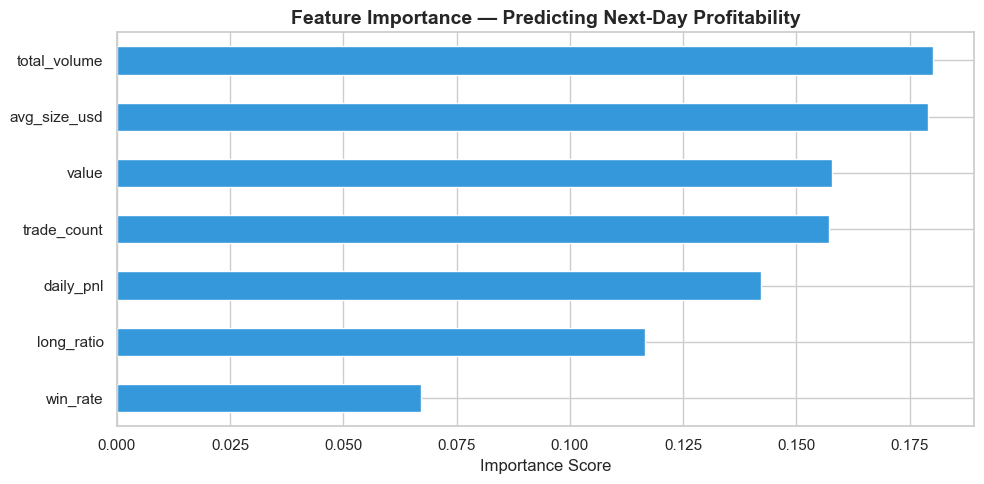

✅ Chart saved!


In [19]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
importances.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Feature Importance — Predicting Next-Day Profitability', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/charts/05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

### Clustering

In [21]:
# KMeans Clustering 

trader_profile = merged.groupby('Account').agg(
    total_pnl       = ('daily_pnl', 'sum'),
    avg_win_rate    = ('win_rate', 'mean'),
    avg_trade_count = ('trade_count', 'mean'),
    avg_trade_size  = ('avg_size_usd', 'mean'),
    avg_long_ratio  = ('long_ratio', 'mean'),
    trading_days    = ('date', 'nunique'),
).reset_index()



In [22]:
cluster_features = ['avg_win_rate','avg_trade_count','avg_trade_size','avg_long_ratio','trading_days']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(trader_profile[cluster_features])

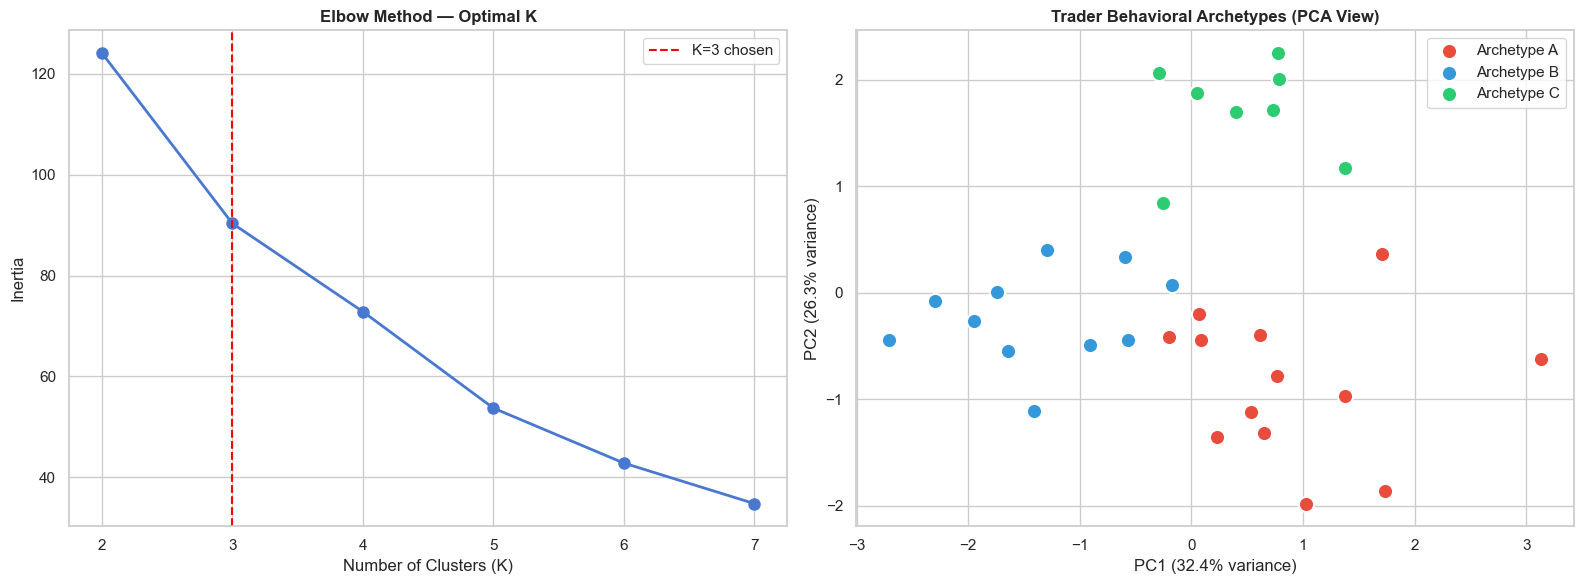


📊 Cluster Profiles:


,avg_win_rate,avg_trade_count,avg_trade_size,avg_long_ratio,trading_days,total_pnl
cluster,,,,,,
0,0.60,185.49,15006.68,0.57,33.77,340613.29
1,0.40,41.92,5169.99,0.37,45.27,155508.74
2,0.73,91.27,3755.37,0.48,175.38,514489.75


In [24]:
# Find best K using Elbow method
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow plot
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Optimal K', fontweight='bold')
axes[0].axvline(x=3, color='red', linestyle='--', label='K=3 chosen')
axes[0].legend()

# Apply K=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_profile['cluster'] = km_final.fit_predict(X_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

cluster_names = {0: 'Archetype A', 1: 'Archetype B', 2: 'Archetype C'}
colors_map = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}

for cluster_id in range(3):
    mask = trader_profile['cluster'] == cluster_id
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors_map[cluster_id], label=cluster_names[cluster_id],
                   s=120, edgecolors='white', linewidth=1.5)

axes[1].set_title('Trader Behavioral Archetypes (PCA View)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/charts/06_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# Cluster profiles
print("\n📊 Cluster Profiles:")
display(trader_profile.groupby('cluster')[cluster_features + ['total_pnl']].mean().round(2))




### INSIGHTS

**The Fear/Greed index score is the 3rd most important feature for predicting next-day trader profitability, outranking win rate — confirming that market sentiment carries real predictive signal beyond what past performance alone provides.**

### ML Model Findings (67.5% accuracy)

**Feature Importance ranking:**

🥇 total_volume (0.18) — how much you trade predicts tomorrow  
🥈 avg_size_usd (0.18) — position size matters most  
🥉 value (0.16) — Fear/Greed index is the 3rd most important predictor!  
trade_count (0.16) — frequency is predictive  
daily_pnl (0.14) — momentum effect  
long_ratio (0.12) — direction bias matters  
win_rate (0.07) — surprisingly least important!  


**The Fear/Greed index score is the 3rd most important feature for predicting next-day trader profitability, outranking win rate — confirming that market sentiment carries real predictive signal beyond what past performance alone provides.**

**The 3 Behavioral Archetypes**

Archetype A (🔴) | Archetype B (🔵) | Archetype C (🟢)
--- | --- | ---
Win Rate | 60% | 40% | 73%
Avg Daily Trades | 185 | 42 | 91
Avg Trade Size | $15,007 | $5,170 | $3,755
Trading Days | 34 | 45 | 175
Total PnL | $340K | $155K | $514K
Label | 🔴 High-Stakes Sprinters | 🔵 Struggling Dabblers | 🟢 Consistent Grinders

The paradox: Archetype C wins the most total money NOT by trading the biggest or most, but by showing up consistently (175 days) with a high win rate. Longevity + discipline > aggression.